# 1. Dataset loading & exploration

Load all scraped JSONs from `data/raw/`, build a DataFrame, and check what we have.

In [ ]:
from concurrent.futures import ThreadPoolExecutor
import json, pandas as pd
from pathlib import Path

RAW_DIR = Path("../data/raw")
paths = list(RAW_DIR.glob("*.json"))

def load(p):
    return json.loads(p.read_bytes())

with ThreadPoolExecutor() as pool:
    records = list(pool.map(load, paths))

df = pd.DataFrame(records)
print(f"Loaded {len(df)} trails")

Loaded 10902 trails


In [ ]:
df = pd.DataFrame(records)
print(df.shape)
df.head(2)

(10902, 45)


,tour_id,url,source,share_url,name,name_original,sport,tour_type,difficulty,difficulty_technical,...,categories,tags,rating_score,rating_count,visitors,author_name,author_id,created_at,changed_at,scraped_at
0,e1000019313,https://www.komoot.com/smarttour/e1000019313,komoot,https://www.komoot.com/smarttour/e1000019313/a...,Acantilados El Bolao y playa de Luaña – circul...,None,mtb,editorial_tour,moderate,dm#t2,...,"[beach, cave, facilities, family_friendly, gor...",[],4.0,1,5,komoot,komoot,2022-12-28T15:58:15.571Z,2024-05-31T09:31:52.508Z,2026-04-28T14:18:49.330561+00:00
1,e1000033768,https://www.komoot.com/smarttour/e1000033768,komoot,https://www.komoot.com/smarttour/e1000033768/p...,Parque Natural de Oyambre – circular desde Com...,None,mtb,editorial_tour,moderate,dm#t2,...,"[cycle_way, facilities, family_friendly, histo...",[],5.0,4,21,komoot,komoot,2022-12-28T16:15:33.068Z,2024-05-31T09:31:52.564Z,2026-04-28T14:35:48.009073+00:00


In [ ]:
# Stats of relevant columns
cols = ["tour_id", "sport", "difficulty", "distance_m", "elevation_up_m",
        "duration_s", "rating_score", "rating_count", "visitors",
        "description", "roundtrip", "region", "country"]

df[cols].describe(include="all")

,tour_id,sport,difficulty,distance_m,elevation_up_m,duration_s,rating_score,rating_count,visitors,description,roundtrip,region,country
count,10902,10902,10902,10902.000000,10902.000000,10902.000000,5209.000000,10902.000000,10902.000000,5642,10902,10431,0
unique,10902,6,3,NaN,NaN,NaN,NaN,NaN,NaN,5642,2,3805,0
top,e999997754,hike,moderate,NaN,NaN,NaN,NaN,NaN,NaN,A difficult 28.2-mile mountain biking route in...,True,Pyrenees,NaN
freq,1,3481,5472,NaN,NaN,NaN,NaN,NaN,NaN,1,10849,65,NaN
mean,NaN,NaN,NaN,33451.558865,559.823681,11324.112915,4.426288,7.313979,67.899835,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,28275.549177,498.650899,6012.587798,0.685285,39.137828,477.502216,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1273.193267,2.317798,990.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,11129.374354,192.574683,6964.500000,4.090909,0.000000,1.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,24500.042668,421.603627,10532.500000,4.620690,0.000000,8.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,49253.170839,792.277911,14706.750000,5.000000,3.000000,34.000000,NaN,NaN,NaN,NaN


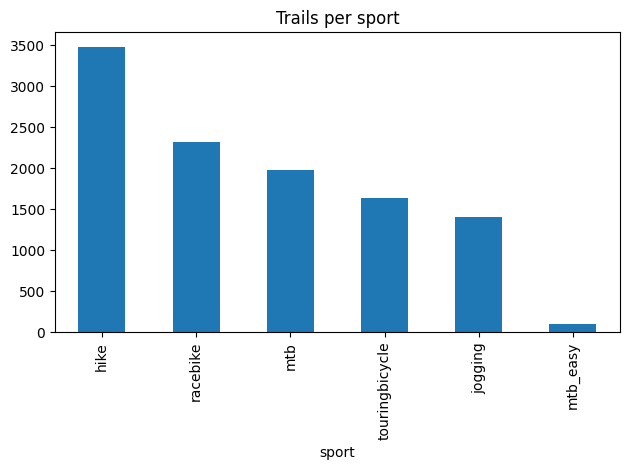

In [ ]:
import matplotlib.pyplot as plt

# trails per sport
df["sport"].value_counts().plot(kind="bar", title="Trails per sport")
plt.tight_layout()
plt.show()

As we can see, for the sports `mtb_easy` and `mtb` there is a variety of difficulties. The category does not provide good information, so we can merge. This also improves the distribution.

In [ ]:
mtb_easy_trails = df[df["sport"] == "mtb_easy"]

print(f"Number of trails with sport 'mtb_easy': {len(mtb_easy_trails)}")

if not mtb_easy_trails.empty:
    print("\nDistribution of 'mtb_easy' trails by difficulty:")
    display(mtb_easy_trails['difficulty'].value_counts().to_frame("Number of 'mtb_easy' trails"))
else:
    print("No trails found with sport 'mtb_easy'.")

In [ ]:
mtb_easy_trails = df[df["sport"] == "mtb"]

print(f"Number of trails with sport 'mtb': {len(mtb_easy_trails)}")

if not mtb_easy_trails.empty:
    print("\nDistribution of 'mtb' trails by difficulty:")
    display(mtb_easy_trails['difficulty'].value_counts().to_frame("Number of 'mtb' trails"))
else:
    print("No trails found with sport 'mtb'.")

In [ ]:
# merge sport categories for mountainbike
df['sport'] = df['sport'].replace(['mtb_easy', 'mtb'], 'mountainbike')

In [ ]:
# drop rows with no description
df = df[df["description"].notna() & (df["description"].str.strip() != "")]
print(f"Trails with description: {len(df)}")

# save clean DataFrame for next notebooks
df.to_pickle("../data/trails.pkl")
print("Saved to data/trails.pkl")

Trails with description: 5642
Saved to data/trails.pkl
